# Notebook 1: Structured Data Processing & Model Training
**Topic:** NLP-Enhanced Knowledge Transfer for Energy Consumption Prediction in Data-Scarce Electric Vehicles

This notebook covers:
- Loading and exploring the EV dataset
- Preprocessing and feature engineering
- EDA and visualization
- Training multiple ML models (Random Forest, XGBoost, LSTM)
- Evaluating and selecting the best model
- Saving models and artifacts for Notebook 3

## Step 1: Install Required Libraries

In [1]:
# Run this cell once to install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow joblib

## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.20.0


## Step 3: Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('../data/EV_Energy_Consumption_Dataset.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (5000, 19)

Column Names: ['Vehicle_ID', 'Timestamp', 'Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Slope_%', 'Weather_Condition', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Energy_Consumption_kWh']

First 5 rows:


,Vehicle_ID,Timestamp,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh
0,1102,2024-01-01 00:00:00,111.507366,-2.773816,30.415148,378.091525,25.314786,2,1,1,6.879446,4,0.741770,42.172533,7.829253,31.112020,1822.967368,20.757508,12.054317
1,1435,2024-01-01 00:01:00,48.612323,-0.796982,97.385534,392.718377,18.240755,1,2,1,-3.007212,4,-3.495516,57.018427,4.495572,31.504366,2091.831914,0.642918,4.488701
2,1860,2024-01-01 00:02:00,108.733320,0.253800,84.912600,398.993495,44.449145,1,1,3,0.029585,1,9.248275,69.028911,5.144489,33.838015,1816.702497,40.842824,11.701377
3,1270,2024-01-01 00:03:00,38.579484,-2.111395,28.777904,358.128273,28.980155,1,2,2,8.271943,3,2.868409,86.638349,4.518283,33.256014,1283.102642,5.305229,7.389266
4,1106,2024-01-01 00:04:00,57.172438,1.477883,29.740160,310.888162,33.184551,2,1,1,2.776814,2,16.750244,27.189185,4.263406,33.579678,2160.350788,5.825926,6.761205


In [4]:
# Basic info
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              5000 non-null   int64  
 1   Timestamp               5000 non-null   object 
 2   Speed_kmh               5000 non-null   float64
 3   Acceleration_ms2        5000 non-null   float64
 4   Battery_State_%         5000 non-null   float64
 5   Battery_Voltage_V       5000 non-null   float64
 6   Battery_Temperature_C   5000 non-null   float64
 7   Driving_Mode            5000 non-null   int64  
 8   Road_Type               5000 non-null   int64  
 9   Traffic_Condition       5000 non-null   int64  
 10  Slope_%                 5000 non-null   float64
 11  Weather_Condition       5000 non-null   int64  
 12  Temperature_C           5000 non-null   float64
 13  Humidity_%              5000 non-null   float64
 14  Wind_Speed_ms           50

,Vehicle_ID,Speed_kmh,Acceleration_ms2,Battery_State_%,Battery_Voltage_V,Battery_Temperature_C,Driving_Mode,Road_Type,Traffic_Condition,Slope_%,Weather_Condition,Temperature_C,Humidity_%,Wind_Speed_ms,Tire_Pressure_psi,Vehicle_Weight_kg,Distance_Travelled_km,Energy_Consumption_kWh
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1505.701200,59.312952,-0.019885,60.214465,351.118306,27.510130,2.011000,1.999200,2.010800,2.504690,2.48340,17.312654,55.302173,7.505087,31.503390,1854.719760,24.994042,8.437983
std,290.836902,34.517605,1.724287,23.128262,28.968372,10.015385,0.810068,0.808536,0.812167,4.360854,1.11372,13.005106,20.161289,4.325455,2.017357,373.685150,14.246454,2.184809
min,1000.000000,0.001396,-2.999683,20.020196,300.004812,10.003858,1.000000,1.000000,1.000000,-4.991079,1.00000,-4.995288,20.027119,0.000126,28.001891,1200.960317,0.107544,1.881426
25%,1253.000000,29.515400,-1.490240,40.088318,326.613439,18.884742,1.000000,1.000000,1.000000,-1.235653,1.00000,5.950476,37.970900,3.837738,29.772709,1531.417633,12.736568,6.771081
50%,1510.000000,58.646794,-0.043329,60.490283,351.510915,27.581710,2.000000,2.000000,2.000000,2.452368,2.00000,17.330798,55.650512,7.495373,31.484048,1865.006523,24.640458,8.455746
75%,1761.000000,89.030001,1.473887,80.409928,375.968140,35.920162,3.000000,3.000000,3.000000,6.366990,3.00000,28.624021,72.650838,11.291284,33.256528,2181.071491,37.562482,10.031938
max,1999.000000,119.946924,2.998039,99.993986,399.990098,44.985943,3.000000,3.000000,3.000000,9.998358,4.00000,39.998063,89.988891,14.999095,34.997829,2499.504564,49.993767,14.660528


## Step 4: Preprocessing

In [5]:
# -----------------------------------------------
# 4.1 - Decode categorical columns
# -----------------------------------------------

# Map numeric codes to readable labels
driving_mode_map   = {1: 'Eco', 2: 'Normal', 3: 'Sport'}
road_type_map      = {1: 'City', 2: 'Highway', 3: 'Rural'}
traffic_map        = {1: 'Low', 2: 'Medium', 3: 'High'}
weather_map        = {1: 'Clear', 2: 'Cloudy', 3: 'Rain', 4: 'Snow'}

df['Driving_Mode_Label']    = df['Driving_Mode'].map(driving_mode_map)
df['Road_Type_Label']       = df['Road_Type'].map(road_type_map)
df['Traffic_Label']         = df['Traffic_Condition'].map(traffic_map)
df['Weather_Label']         = df['Weather_Condition'].map(weather_map)

print('Categorical columns decoded!')
print('Driving Modes:', df['Driving_Mode_Label'].unique())
print('Road Types:', df['Road_Type_Label'].unique())
print('Traffic Conditions:', df['Traffic_Label'].unique())
print('Weather Conditions:', df['Weather_Label'].unique())

Categorical columns decoded!
Driving Modes: ['Normal' 'Eco' 'Sport']
Road Types: ['City' 'Highway' 'Rural']
Traffic Conditions: ['Low' 'High' 'Medium']
Weather Conditions: ['Snow' 'Clear' 'Rain' 'Cloudy']


In [ ]:
# -----------------------------------------------
# 4.2 - Feature Engineering
# -----------------------------------------------

# Convert Timestamp to datetime features
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month']     = df['Timestamp'].dt.month

# Create interaction features
df['Speed_x_Weight']       = df['Speed_kmh'] * df['Vehicle_Weight_kg']  #kinetic energy to pull heavier vehicle
df['Temp_x_Battery']       = df['Temperature_C'] * df['Battery_State_%']  #thermal condition
df['Accel_x_Speed']        = df['Acceleration_ms2'] * df['Speed_kmh']  #aggrisiveness
df['Wind_Resistance']      = df['Wind_Speed_ms'] ** 2  # aerodynamic drag proxy

print('New features created!')
print('Total features now:', df.shape[1])

New features created!
Total features now: 30


In [7]:
# -----------------------------------------------
# 4.3 - Define Features and Target
# -----------------------------------------------

# Drop non-feature columns
drop_cols = ['Vehicle_ID', 'Timestamp', 
             'Driving_Mode_Label', 'Road_Type_Label', 
             'Traffic_Label', 'Weather_Label']

feature_cols = [col for col in df.columns 
                if col not in drop_cols + ['Energy_Consumption_kWh']]

X = df[feature_cols]
y = df['Energy_Consumption_kWh']

print('Feature columns:', feature_cols)
print('\nX shape:', X.shape)
print('y shape:', y.shape)
print('Target range: {:.2f} - {:.2f} kWh'.format(y.min(), y.max()))

Feature columns: ['Speed_kmh', 'Acceleration_ms2', 'Battery_State_%', 'Battery_Voltage_V', 'Battery_Temperature_C', 'Driving_Mode', 'Road_Type', 'Traffic_Condition', 'Slope_%', 'Weather_Condition', 'Temperature_C', 'Humidity_%', 'Wind_Speed_ms', 'Tire_Pressure_psi', 'Vehicle_Weight_kg', 'Distance_Travelled_km', 'Hour', 'DayOfWeek', 'Month', 'Speed_x_Weight', 'Temp_x_Battery', 'Accel_x_Speed', 'Wind_Resistance']

X shape: (5000, 23)
y shape: (5000,)
Target range: 1.88 - 14.66 kWh


In [8]:
# -----------------------------------------------
# 4.4 - Train/Test Split and Scaling
# -----------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('Scaler fitted!')

Train size: (4000, 23)
Test size: (1000, 23)
Scaler fitted!


## Step 5: Exploratory Data Analysis (EDA)

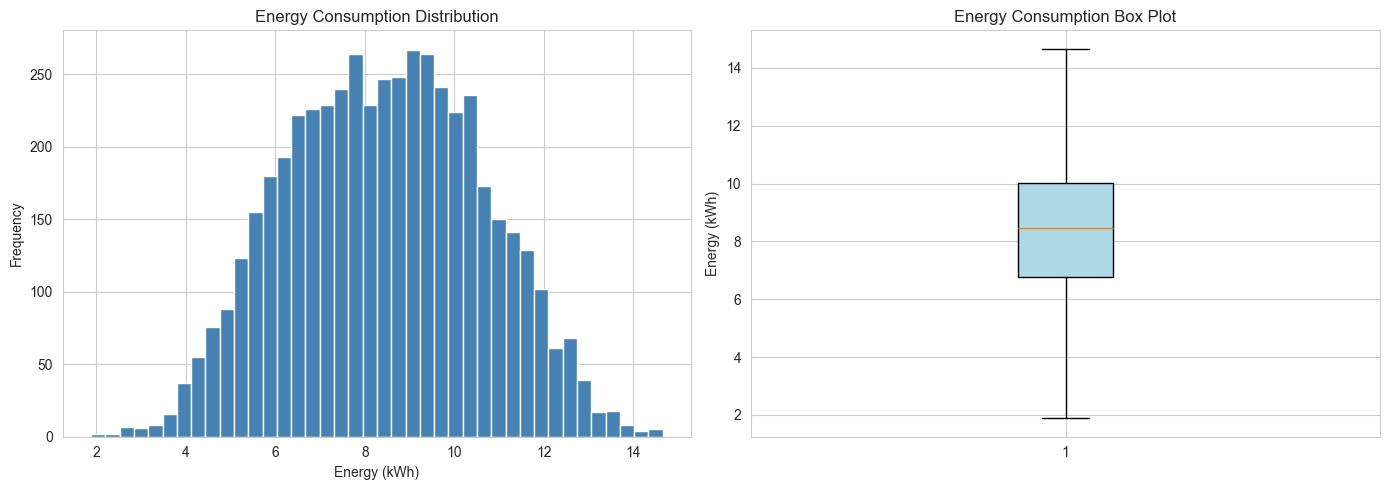

Mean Energy: 8.438 kWh
Std  Energy: 2.185 kWh


In [9]:
# -----------------------------------------------
# 5.1 - Target Distribution
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Energy Consumption Distribution')
axes[0].set_xlabel('Energy (kWh)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Energy Consumption Box Plot')
axes[1].set_ylabel('Energy (kWh)')

plt.tight_layout()
plt.savefig('../results/target_distribution.png', dpi=150)
plt.show()
print('Mean Energy:', round(y.mean(), 3), 'kWh')
print('Std  Energy:', round(y.std(), 3), 'kWh')

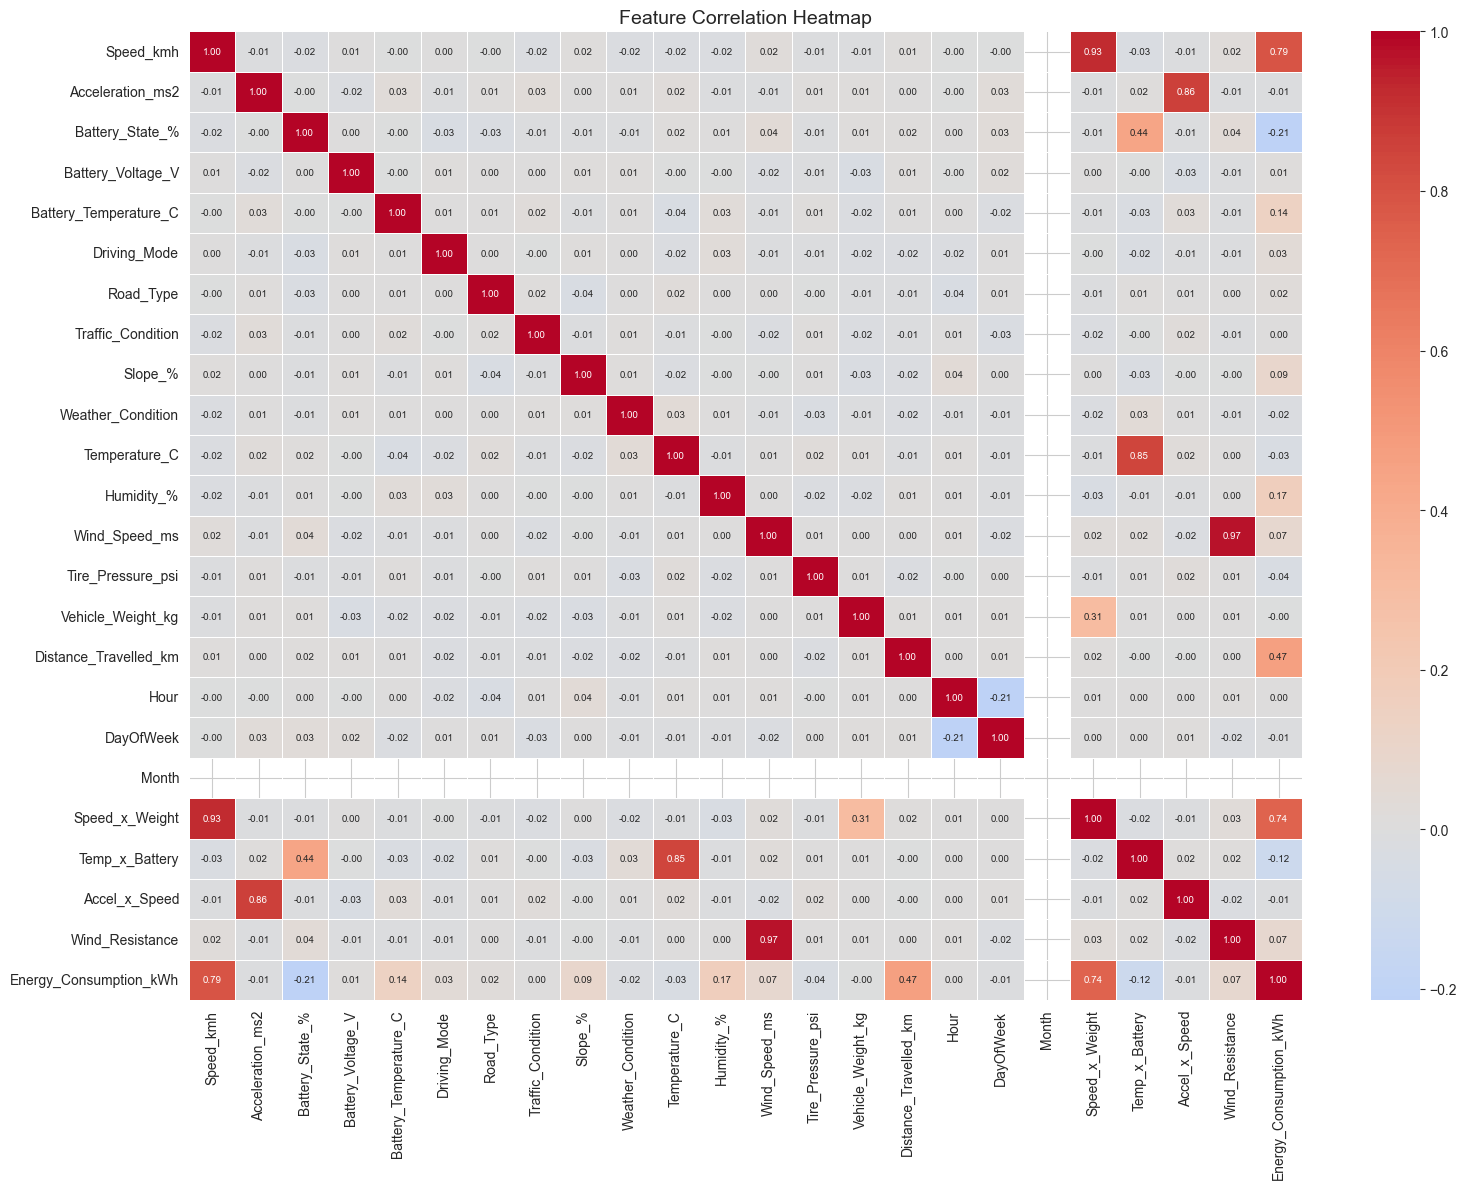

In [10]:
# -----------------------------------------------
# 5.2 - Correlation Heatmap
# -----------------------------------------------

numeric_cols = df[feature_cols + ['Energy_Consumption_kWh']].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_cols, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150)
plt.show()

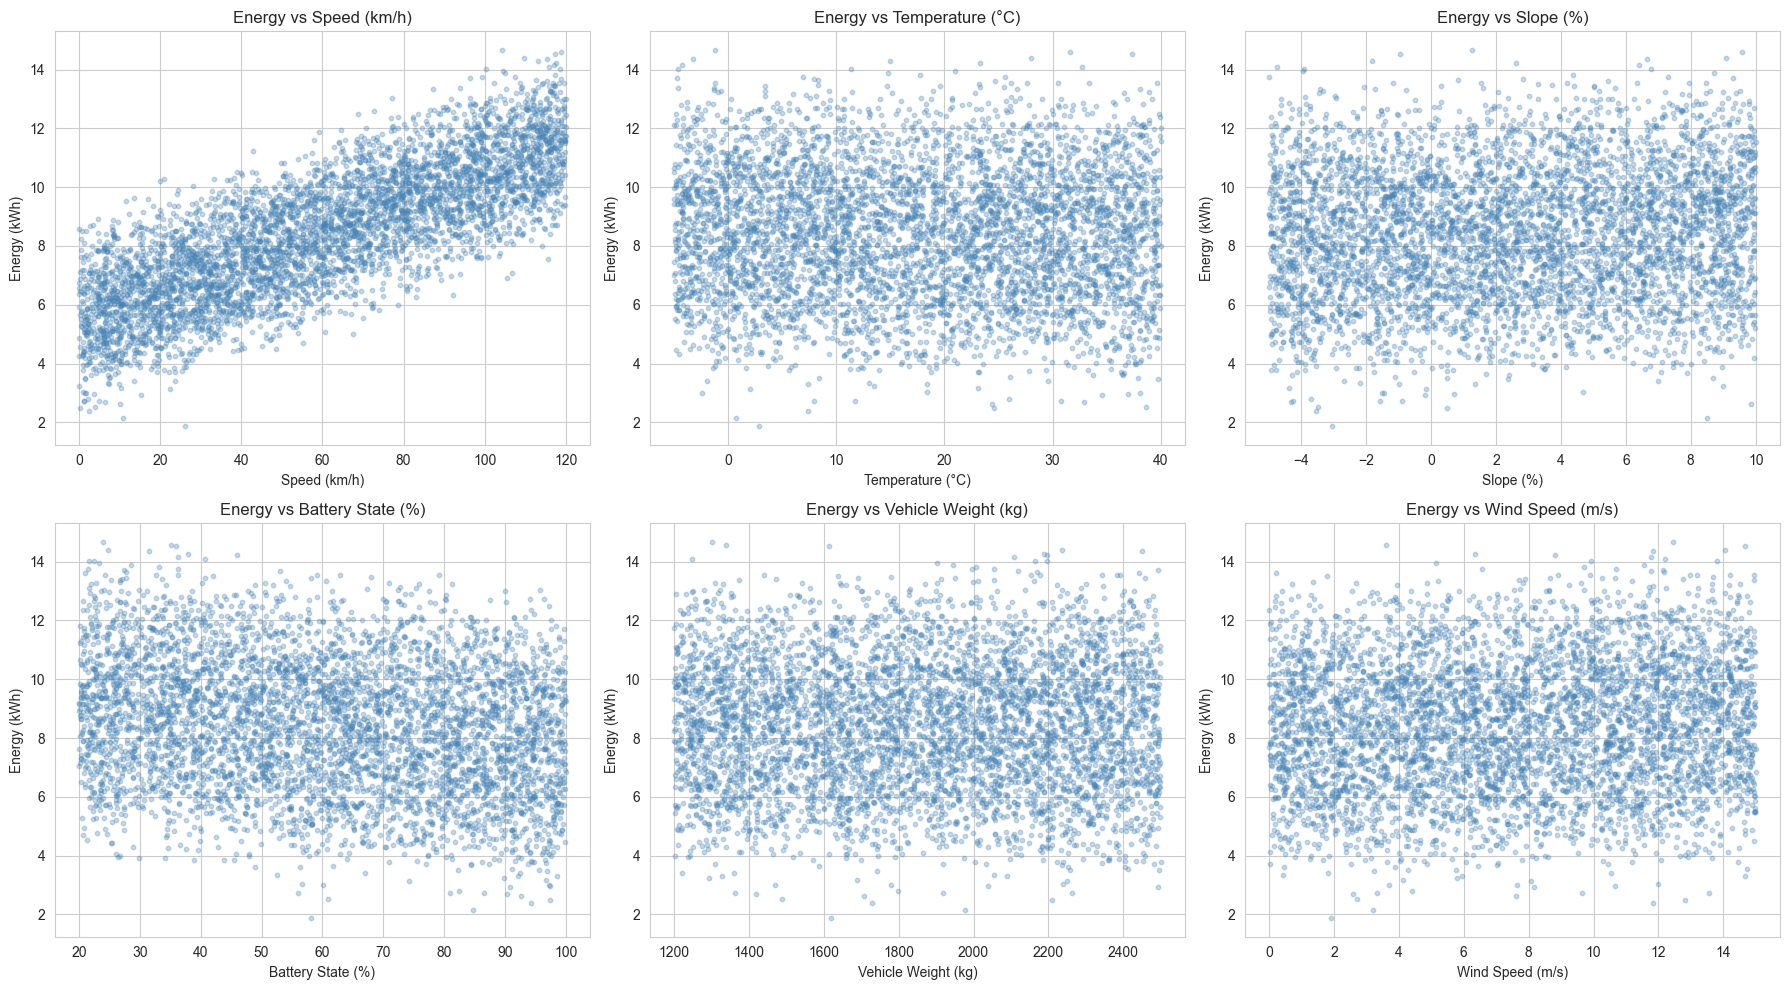

In [11]:
# -----------------------------------------------
# 5.3 - Key Feature Relationships
# -----------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    ('Speed_kmh', 'Speed (km/h)'),
    ('Temperature_C', 'Temperature (°C)'),
    ('Slope_%', 'Slope (%)'),
    ('Battery_State_%', 'Battery State (%)'),
    ('Vehicle_Weight_kg', 'Vehicle Weight (kg)'),
    ('Wind_Speed_ms', 'Wind Speed (m/s)')
]

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['Energy_Consumption_kWh'], 
               alpha=0.3, color='steelblue', s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Energy (kWh)')
    ax.set_title(f'Energy vs {label}')

plt.tight_layout()
plt.savefig('../results/feature_relationships.png', dpi=150)
plt.show()

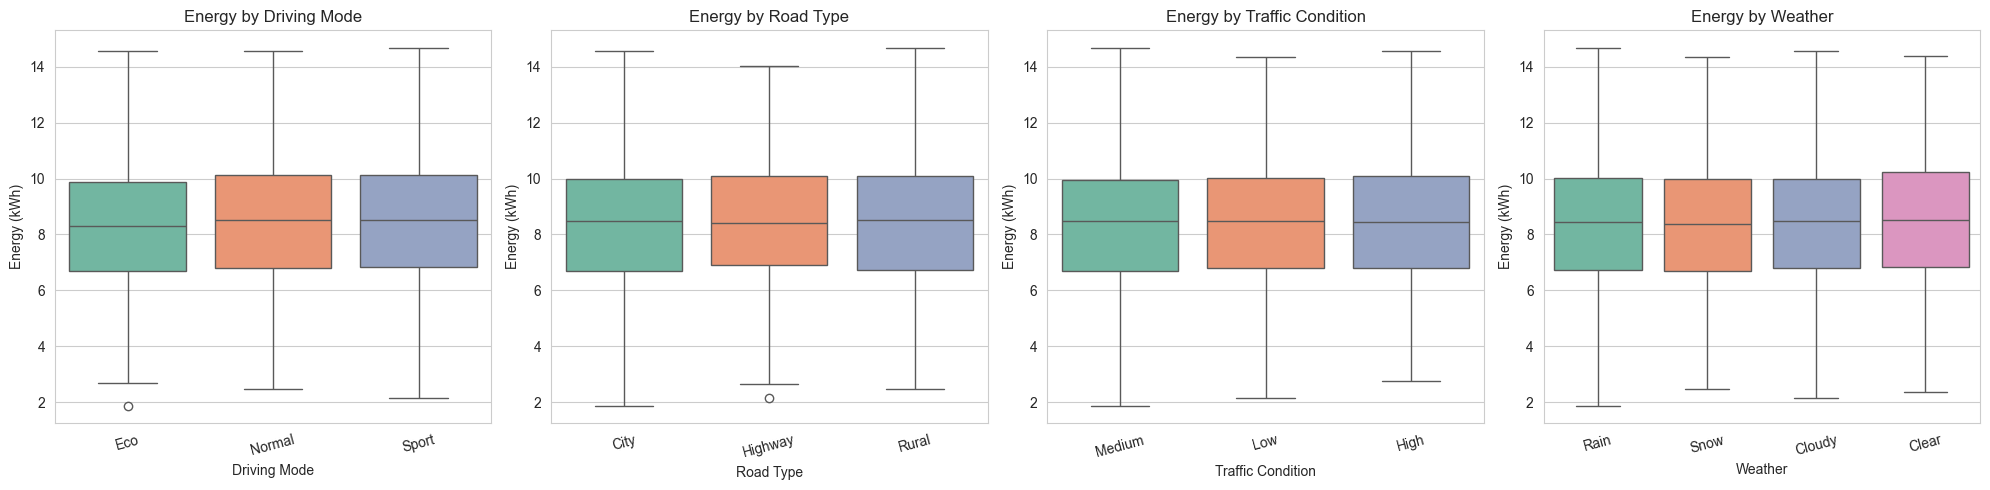

In [12]:
# -----------------------------------------------
# 5.4 - Energy by Categorical Features
# -----------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

cats = [
    ('Driving_Mode_Label', 'Driving Mode'),
    ('Road_Type_Label', 'Road Type'),
    ('Traffic_Label', 'Traffic Condition'),
    ('Weather_Label', 'Weather')
]

for ax, (col, title) in zip(axes, cats):
    order = df.groupby(col)['Energy_Consumption_kWh'].mean().sort_values().index
    sns.boxplot(data=df, x=col, y='Energy_Consumption_kWh',
                order=order, ax=ax, palette='Set2')
    ax.set_title(f'Energy by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Energy (kWh)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/energy_by_category.png', dpi=150)
plt.show()

## Step 6: Model Training

In [13]:
# Helper function to evaluate any model
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n--- {name} ---')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []  # store all model results

In [14]:
# -----------------------------------------------
# 6.1 - Random Forest
# -----------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_results = evaluate_model('Random Forest', y_test, rf_pred)
results.append(rf_results)


--- Random Forest ---
  MAE  : 0.5227
  RMSE : 0.6560
  R²   : 0.9112


In [15]:
# -----------------------------------------------
# 6.2 - XGBoost
# -----------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_test_scaled, y_test)],
              verbose=False)
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_results = evaluate_model('XGBoost', y_test, xgb_pred)
results.append(xgb_results)


--- XGBoost ---
  MAE  : 0.4831
  RMSE : 0.6046
  R²   : 0.9246


In [16]:
# -----------------------------------------------
# 6.3 - LSTM
# -----------------------------------------------

# LSTM needs 3D input: (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

n_features = X_train_scaled.shape[1]

lstm_model = Sequential([
    LSTM(128, input_shape=(1, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

lstm_pred = lstm_model.predict(X_test_lstm).flatten()
lstm_results = evaluate_model('LSTM', y_test, lstm_pred)
results.append(lstm_results)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,857 (507.25 KB)

 Trainable params: 129,857 (507.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 51.3280 - mae: 6.4105 - val_loss: 1.0900 - val_mae: 0.8376
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2729 - mae: 0.9002 - val_loss: 0.5017 - val_mae: 0.5533
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9991 - mae: 0.7889 - val_loss: 0.4200 - val_mae: 0.5076
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8976 - mae: 0.7445 - val_loss: 0.3971 - val_mae: 0.4978
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8027 - mae: 0.7116 - val_loss: 0.3711 - val_mae: 0.4833
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7582 - mae: 0.6971 - val_loss: 0.3279 - val_mae: 0.4557
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7111 - mae: 0.6678 - val_loss: 0.3278 - val_mae: 0.4536
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6453 - mae: 0.6399 - val_loss: 0.3312 - val_mae: 0.4578
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

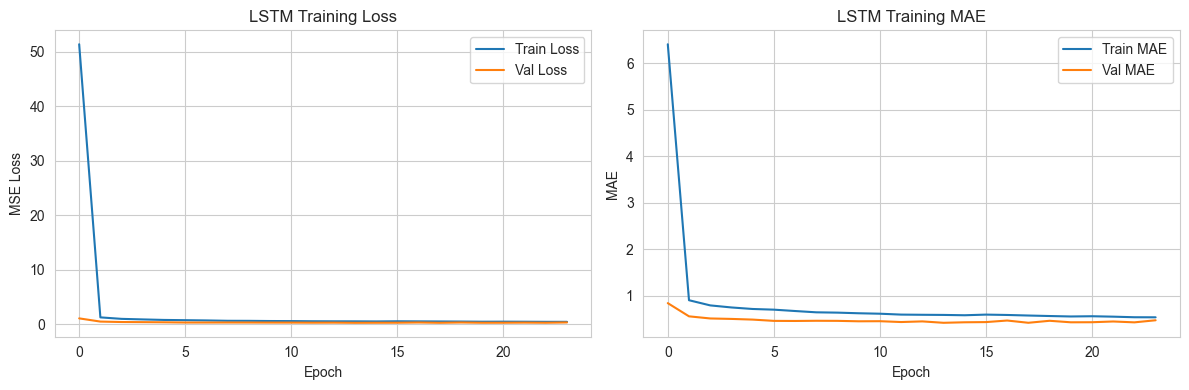

In [17]:
# -----------------------------------------------
# 6.4 - LSTM Training History Plot
# -----------------------------------------------

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('LSTM Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('../results/lstm_training_history.png', dpi=150)
plt.show()

## Step 7: Model Comparison

In [18]:
# -----------------------------------------------
# 7.1 - Results Table
# -----------------------------------------------

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print('\n===== MODEL COMPARISON =====')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest Model: {best_model_name}')

# Save results
results_df.to_csv('../results/model_comparison.csv', index=False)
print('Results saved to ../results/model_comparison.csv')


===== MODEL COMPARISON =====
        Model      MAE     RMSE       R2
         LSTM 0.436911 0.549294 0.937779
      XGBoost 0.483135 0.604562 0.924629
Random Forest 0.522662 0.656041 0.911246

Best Model: LSTM
Results saved to ../results/model_comparison.csv


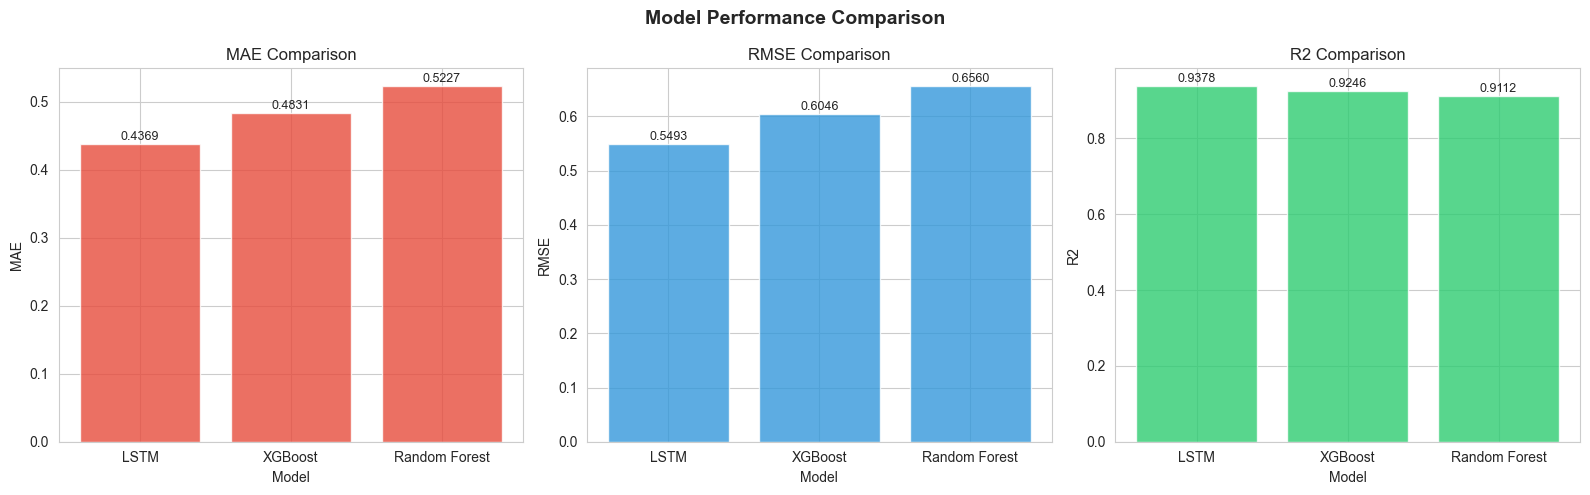

In [19]:
# -----------------------------------------------
# 7.2 - Model Comparison Chart
# -----------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric], color=color, alpha=0.8)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/model_comparison_chart.png', dpi=150)
plt.show()

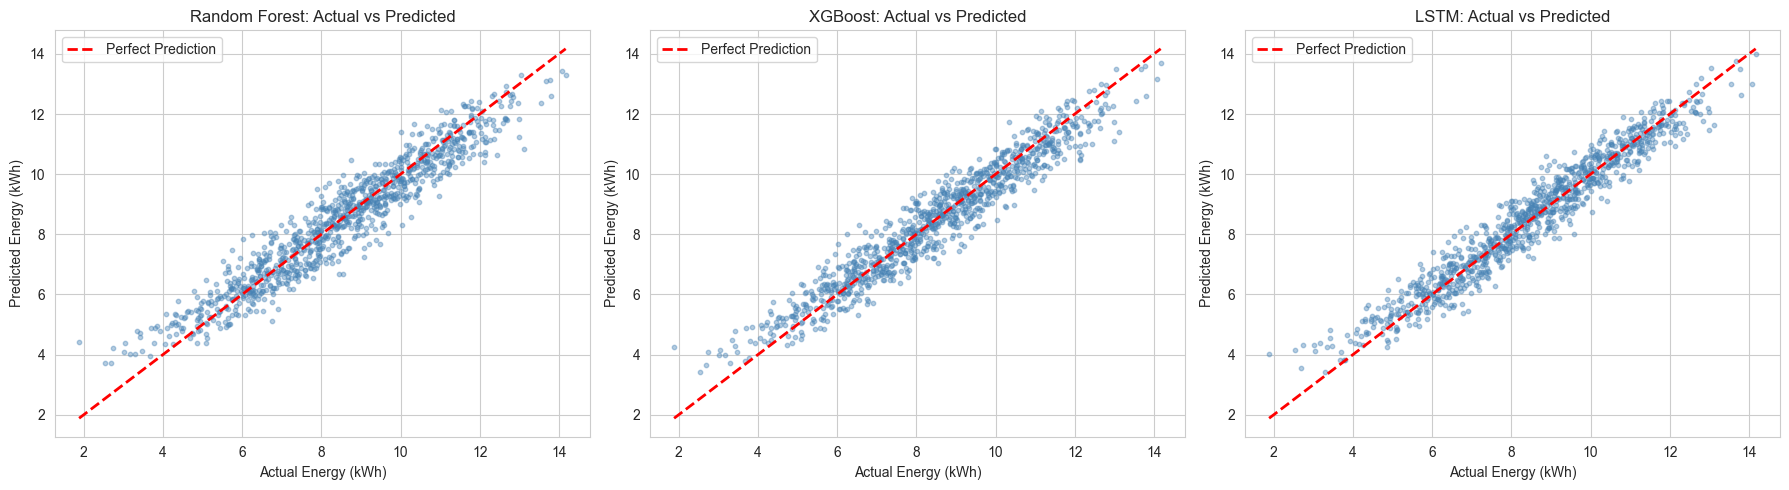

In [20]:
# -----------------------------------------------
# 7.3 - Actual vs Predicted Plot (All Models)
# -----------------------------------------------

all_preds = {'Random Forest': rf_pred, 'XGBoost': xgb_pred, 'LSTM': lstm_pred}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.scatter(y_test, pred, alpha=0.4, s=10, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Energy (kWh)')
    ax.set_ylabel('Predicted Energy (kWh)')
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/actual_vs_predicted.png', dpi=150)
plt.show()

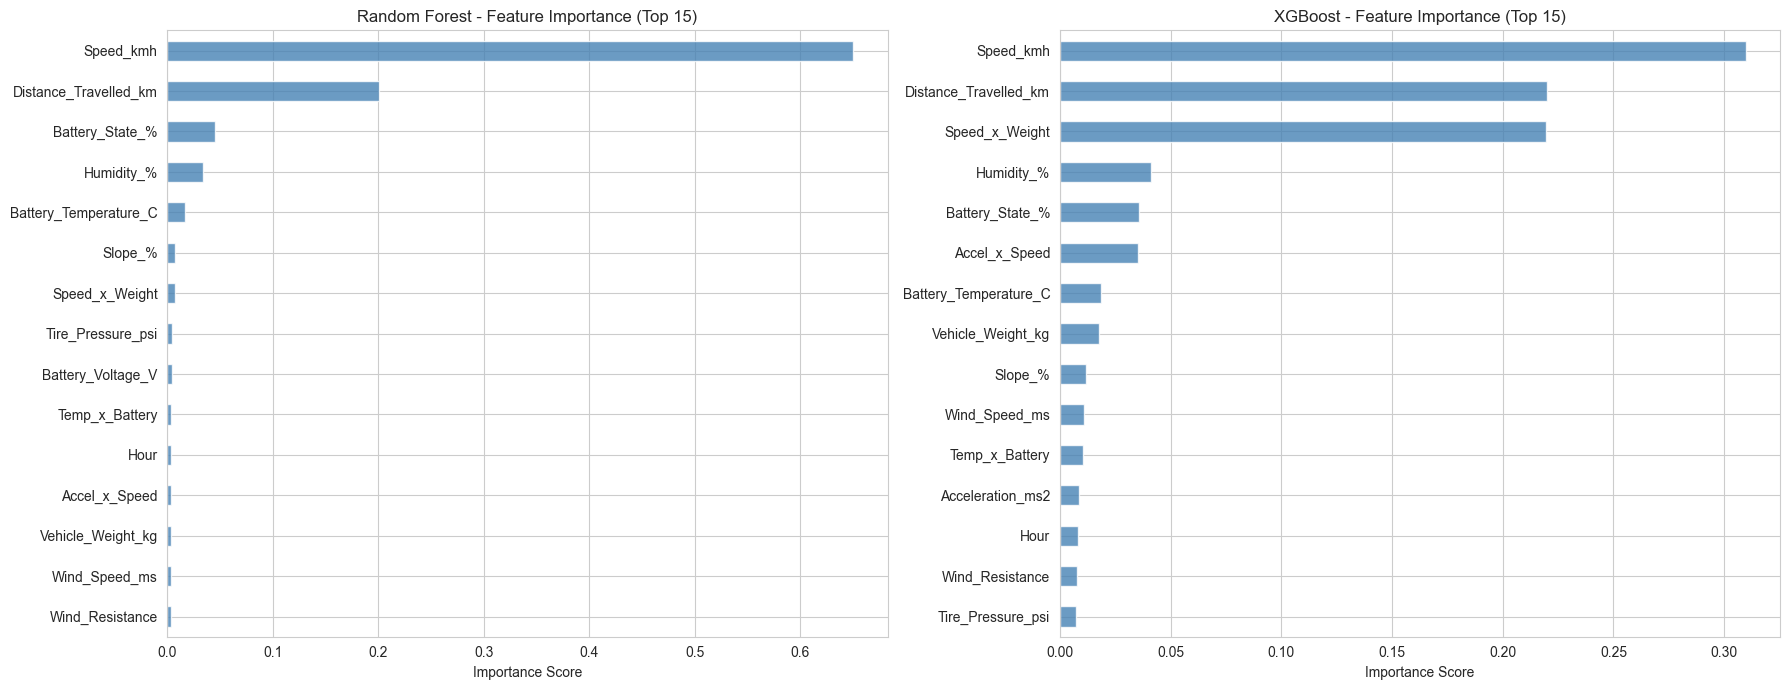

Feature importance saved!


In [21]:
# -----------------------------------------------
# 7.4 - Feature Importance (Random Forest & XGBoost)
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, name in zip(axes, [rf_model, xgb_model], ['Random Forest', 'XGBoost']):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'{name} - Feature Importance (Top 15)')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150)
plt.show()

# Save feature importance
fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf_model.feature_importances_,
    'XGB_Importance': xgb_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

fi_df.to_csv('../results/feature_importance.csv', index=False)
print('Feature importance saved!')

## Step 8: Save All Models and Artifacts

In [22]:
os.makedirs('../saved_models', exist_ok=True)

# Save Random Forest
joblib.dump(rf_model, '../saved_models/random_forest_model.pkl')
print('Random Forest saved!')

# Save XGBoost
joblib.dump(xgb_model, '../saved_models/xgboost_model.pkl')
print('XGBoost saved!')

# Save LSTM
lstm_model.save('../saved_models/lstm_model.keras')
print('LSTM saved!')

# Save Scaler
joblib.dump(scaler, '../saved_models/scaler.pkl')
print('Scaler saved!')

# Save feature columns list
joblib.dump(feature_cols, '../saved_models/feature_cols.pkl')
print('Feature columns saved!')

# Save best model name
joblib.dump(best_model_name, '../saved_models/best_model_name.pkl')
print(f'\nAll models saved! Best model: {best_model_name}')

# Save test predictions for later comparison
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'RF_Pred': rf_pred,
    'XGB_Pred': xgb_pred,
    'LSTM_Pred': lstm_pred
})
pred_df.to_csv('../results/structured_predictions.csv', index=False)
print('Predictions saved to results folder!')

Random Forest saved!
XGBoost saved!
LSTM saved!
Scaler saved!
Feature columns saved!

All models saved! Best model: LSTM
Predictions saved to results folder!


In [23]:
print('='*50)
print('NOTEBOOK 1 COMPLETE!')
print('='*50)
print(f'Best Structured Model : {best_model_name}')
print(f'Best R² Score         : {results_df.iloc[0]["R2"]:.4f}')
print(f'Best MAE              : {results_df.iloc[0]["MAE"]:.4f} kWh')
print(f'Best RMSE             : {results_df.iloc[0]["RMSE"]:.4f} kWh')
print('\nFiles saved:')
print('  saved_models/random_forest_model.pkl')
print('  saved_models/xgboost_model.pkl')
print('  saved_models/lstm_model.h5')
print('  saved_models/scaler.pkl')
print('  saved_models/feature_cols.pkl')
print('  results/model_comparison.csv')
print('  results/feature_importance.csv')
print('  results/structured_predictions.csv')
print('\nReady for Notebook 2 (NLP Pipeline)!')

NOTEBOOK 1 COMPLETE!
Best Structured Model : LSTM
Best R² Score         : 0.9378
Best MAE              : 0.4369 kWh
Best RMSE             : 0.5493 kWh

Files saved:
  saved_models/random_forest_model.pkl
  saved_models/xgboost_model.pkl
  saved_models/lstm_model.h5
  saved_models/scaler.pkl
  saved_models/feature_cols.pkl
  results/model_comparison.csv
  results/feature_importance.csv
  results/structured_predictions.csv

Ready for Notebook 2 (NLP Pipeline)!
